In [1]:
# ==============================
# IMPORT LIBRARIES
# ==============================
import time
import multiprocessing
import matplotlib.pyplot as plt

In [2]:
# ==============================
# SEQUENTIAL REDUCTION
# ==============================
def sequential_reduction(arr):
    min_val = min(arr)
    max_val = max(arr)
    total = sum(arr)
    avg = total / len(arr)
    return min_val, max_val, total, avg

In [3]:
# ==============================
# PARALLEL FUNCTIONS
# ==============================
def find_min(arr):
    return min(arr)

def find_max(arr):
    return max(arr)

def find_sum(arr):
    return sum(arr)

In [4]:
# ==============================
# PARALLEL REDUCTION
# ==============================
def parallel_reduction(arr):
    with multiprocessing.Pool(3) as pool:
        min_val, max_val, total = pool.map(
            lambda func: func(arr),
            [find_min, find_max, find_sum]
        )
    avg = total / len(arr)
    return min_val, max_val, total, avg

In [5]:
# ==============================
# USER INPUT
# ==============================
n = int(input("Enter number of elements: "))
arr = list(map(int, input("Enter elements: ").split()))

Enter number of elements: 5
Enter elements: 12 86 35 81 54


In [6]:
# ==============================
# TIME MEASUREMENT
# ==============================
start = time.time()
seq_result = sequential_reduction(arr)
end = time.time()
seq_time = end - start

# Helper function must be defined at a module level or similar to be picklable
def _apply_func_to_arr_helper(func, arr_data):
    return func(arr_data)

# Redefining parallel_reduction in this cell to fix the pickling issue
def parallel_reduction(arr_to_process):
    with multiprocessing.Pool(3) as pool:
        # Prepare tasks for starmap: a list of tuples, each containing (function, array)
        tasks = [(func, arr_to_process) for func in [find_min, find_max, find_sum]]
        # Use starmap with the picklable helper function
        results = pool.starmap(_apply_func_to_arr_helper, tasks)
        min_val, max_val, total = results
    avg = total / len(arr_to_process)
    return min_val, max_val, total, avg

start = time.time()
par_result = parallel_reduction(arr)
end = time.time()
par_time = end - start

In [7]:
# ==============================
# OUTPUT
# ==============================
print("\nSequential Result (Min, Max, Sum, Avg):", seq_result)
print("Parallel Result (Min, Max, Sum, Avg):", par_result)

print("\nSequential Time:", seq_time)
print("Parallel Time:", par_time)


Sequential Result (Min, Max, Sum, Avg): (12, 86, 268, 53.6)
Parallel Result (Min, Max, Sum, Avg): (12, 86, 268, 53.6)

Sequential Time: 7.271766662597656e-05
Parallel Time: 0.037835121154785156


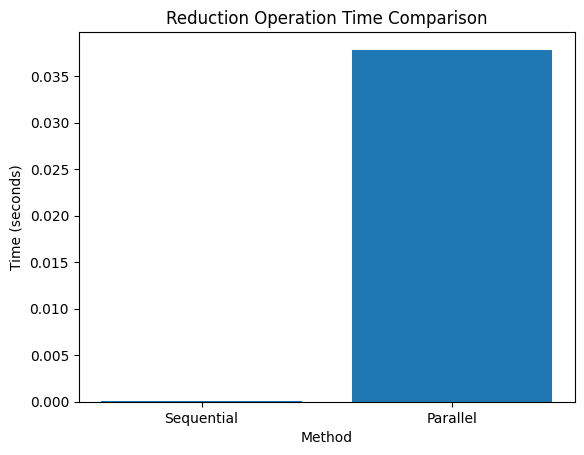

In [8]:
# ==============================
# GRAPH: TIME COMPARISON
# ==============================
plt.figure()

methods = ["Sequential", "Parallel"]
times = [seq_time, par_time]

plt.bar(methods, times)
plt.title("Reduction Operation Time Comparison")
plt.xlabel("Method")
plt.ylabel("Time (seconds)")

plt.show()